# Linear Regression

## 1. Regression vs. Classification: 
- A problem is categorized as a regression task when the target variable $y$ is continuous, whereas classification deals with discrete categorical labels.

## 2. Structural Workflow of Supervised Learning

- The system architecture follows a continuous data-to-prediction pipeline:

```mermaid
graph TD
    %% Training Phase
    subgraph Training_Phase [Phase 1: Model Training]
    A[Training Set] --> B[Learning Algorithm]
    end

    %% Connection from Algorithm to Hypothesis
    B -->|outputs| C

    %% Prediction Phase
    subgraph Prediction_Phase [Phase 2: Inference/Prediction]
    D[New Feature x] --> C[Hypothesis h]
    C --> E[Estimated Output ŷ]
    end

    %% Styling
    style B fill:#f9f,stroke:#333,stroke-width:2px
    style C fill:#bbf,stroke:#333,stroke-width:2px
    style Training_Phase fill:#f5f5f5,stroke:#666,stroke-dasharray: 5 5
    style Prediction_Phase fill:#f5f5f5,stroke:#666,stroke-dasharray: 5 5
```

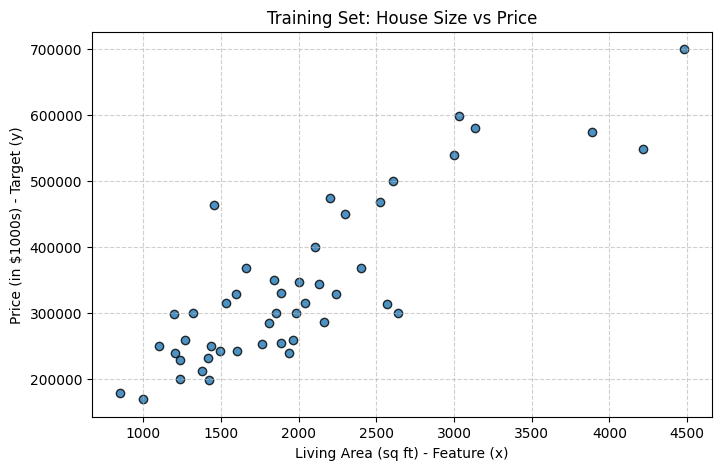

In [1]:
# House Size vs. Price dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data/housing.csv')

# Plotting the dataset to visualize the distribution
plt.figure(figsize=(8, 5))
plt.scatter(df['size'], df['price'], color='#1f77b4', edgecolors='k', alpha=0.8)
plt.title('Training Set: House Size vs Price')
plt.xlabel('Living Area (sq ft) - Feature (x)')
plt.ylabel('Price (in $1000s) - Target (y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [2]:
df.head()

,size,bedrooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


# Linear Regression and Gradient Descent

## 1. The Hypothesis Function

Linear Regression models the relationship between input features and a continuous target variable using a linear hypothesis function.

### 1.1 Simple Linear Regression (Single Feature)

For a univariable system $(n = 1)$, where $x$ may represent the square footage of a house:

$$
h_\t\(\t(\theta)  \) (x) = \t\(\t(\theta)  \) _0 + \t\(\t(\theta)  \) _1 x
$$

Where:

- $\t\(\t(\theta)  \) _0$ → Bias (intercept)
- $\t\(\t(\theta)  \) _1$ → Weight (slope)
- $x$ → Input feature

---

### 1.2 Multiple Linear Regression (Multiple Features)

For a generalized multi-feature system $(n \ge 2)$:

$$
h_\t\(\t(\theta)  \) (x) = \t\(\t(\theta)  \) _0 + \t\(\t(\theta)  \) _1x_1 + \t\(\t(\theta)  \) _2x_2 + \dots + \t\(\t(\theta)  \) _nx_n
$$

Vectorized representation:

$$
h_\t\(\t(\theta)  \) (x) = \sum_{j=0}^{n}\t\(\t(\theta)  \) _jx_j = \t\(\t(\theta)  \) ^Tx
$$

Where:

$$
\t\(\t(\theta)  \)  =
\begin{bmatrix}
\t\(\t(\theta)  \) _0 \\
\t\(\t(\theta)  \) _1 \\
\vdots \\
\t\(\t(\theta)  \) _n
\end{bmatrix}
\in \mathbb{R}^{n+1}
\quad , \quad
x =
\begin{bmatrix}
x_0 \\
x_1 \\
\vdots \\
x_n
\end{bmatrix}
\in \mathbb{R}^{n+1}
$$

with:

$$
x_0 = 1
$$

---

### 1.3 Training Dataset

The model learns from a dataset consisting of:

$$
(x^{(i)}, y^{(i)})
$$

Where:

- $x^{(i)}$ → Feature vector of the $i^{th}$ training example
- $y^{(i)}$ → Ground truth target value
- $m$ → Number of training examples

The objective is:

$$
h_\t\(\t(\theta)  \) (x^{(i)}) \approx y^{(i)}
$$

---

# 2. The Cost Function

To evaluate model performance, we measure the difference between predictions and actual target values.

The residual error for a single example is:

$$
(h_\t\(\t(\theta)  \) (x) - y)
$$

To penalize larger errors more strongly and ensure differentiability, the error is squared.

---

## 2.1 Mean Squared Error (MSE)

The implementation uses the Mean Squared Error (MSE) cost function:

$$
J(\t\(\t(\theta)  \) )=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Expanded form:

$$
J(\t\(\t(\theta)  \) )
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
h_\t\(\t(\theta)  \) (x^{(i)}) - y^{(i)}
\right)^2
$$

Where:

- $J(\t\(\t(\theta)  \) )$ → Cost function
- $m$ → Total training examples
- $\hat{y}_i$ → Predicted value
- $y_i$ → Actual value

The goal of training is:

$$
\min_\t\(\t(\theta)  \)  J(\t\(\t(\theta)  \) )
$$

---

# 3. Batch Gradient Descent Optimization

Gradient Descent is a first-order optimization algorithm used to minimize the cost function iteratively.

The algorithm updates parameters by moving in the direction of the negative gradient.

---

## 3.1 General Update Rule

Parameters are initialized (typically with zeros or small random values) and updated simultaneously:

$$
\t\(\t(\theta)  \) _j
:=
\t\(\t(\theta)  \) _j
-
\alpha
\frac{\partial}{\partial \t\(\t(\theta)  \) _j}J(\t\(\t(\theta)  \) )
$$

Where:

- $\alpha$ → Learning rate
- $\frac{\partial}{\partial \t\(\t(\theta)  \) _j}J(\t\(\t(\theta)  \) )$ → Partial derivative of the cost function
- `:=` → Assignment operator

Weight update rule:

$$
w:=w-\alpha\frac{\partial J}{\partial w}
$$

Bias update rule:

$$
b:=b-\alpha\frac{\partial J}{\partial b}
$$

---

# 4. Derivation of Gradients

Consider the hypothesis function:

$$
\hat{y} = wx + b
$$

The cost function:

$$
J(w,b)
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i - y_i)^2
$$

---

## 4.1 Gradient with Respect to Weight

Using partial differentiation:

$$
\frac{\partial J}{\partial w}
=
\frac{2}{m}
\sum_{i=1}^{m}
(\hat{y}_i - y_i)x_i
$$

---

## 4.2 Gradient with Respect to Bias

$$
\frac{\partial J}{\partial b}
=
\frac{2}{m}
\sum_{i=1}^{m}
(\hat{y}_i - y_i)
$$

These are the exact equations implemented in the Python code:

```python
dw = (2 / n_samples) * np.sum((predictions - y) * x)
db = (2 / n_samples) * np.sum(predictions - y)

In [16]:
! pip3 install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from __future__ import annotations

import numpy as np
import pandas as pd



class LinearRegressionBGD:
    """
    Multiple Linear Regression using Batch Gradient Descent.
    """

    def __init__(
        self,
        learning_rate: float = 0.01,
        epochs: int = 1000,
    ) -> None:

        self.learning_rate = learning_rate
        self.epochs = epochs

        # Parameters
        self.weight: np.ndarray | None = None
        self.bias: float = 0.0

        # Store training loss
        self.loss_history: list[float] = []

    def fit(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> None:
        """
        Train model using Batch Gradient Descent.
        """

        # Number of samples and features
        n_samples, n_features = x.shape

        # Initialize parameters
        self.weight = np.zeros(n_features)
        self.bias = 0.0

        # Gradient Descent Loop
        for epoch in range(self.epochs):

            # Forward Pass
            predictions = self.predict(x)

            # Compute Loss
            loss = np.mean(
                (predictions - y) ** 2
            )

            self.loss_history.append(loss)

            # Compute Gradients
            dw = (
                2 / n_samples
            ) * np.dot(
                x.T,
                (predictions - y),
            )

            db = (
                2 / n_samples
            ) * np.sum(
                predictions - y
            )

            # Update Parameters
            self.weight -= (
                self.learning_rate * dw
            )

            self.bias -= (
                self.learning_rate * db
            )

            # Print Training Progress
            if epoch % 100 == 0:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Loss: {loss:.6f}"
                )

    def predict(
        self,
        x: np.ndarray,
    ) -> np.ndarray:
        """
        Predict target values.
        """

        if self.weight is None:
            raise ValueError(
                "Model not trained yet."
            )

        return np.dot(
            x,
            self.weight,
        ) + self.bias

    def score(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> float:
        """
        Compute R² score.
        """

        predictions = self.predict(x)

        ss_total = np.sum(
            (y - np.mean(y)) ** 2
        )

        ss_residual = np.sum(
            (y - predictions) ** 2
        )

        return 1 - (
            ss_residual / ss_total
        )



if __name__ == "__main__":

    # -----------------------------------
    # Load Dataset
    # -----------------------------------
    df = pd.read_csv(
        "./data/housing.csv"
    )

    print("\nDataset Preview")
    print("----------------")
    print(df.head())

    # -----------------------------------
    # Features and Target
    # -----------------------------------
    X = df.drop(
        columns=["price"]
    ).values.astype(np.float64)

    y = df["price"].values.astype(
        np.float64
    )

    # -----------------------------------
    # Train/Test Split
    # -----------------------------------
    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.33,
            random_state=42,
        )
    )

    print("\nDataset Shapes")
    print("----------------")
    print(f"X_train: {X_train.shape}")
    print(f"X_test : {X_test.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"y_test : {y_test.shape}")

    # -----------------------------------
    # Feature Scaling
    # -----------------------------------
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    # -----------------------------------
    # Initialize Model
    # -----------------------------------
    model = LinearRegressionBGD(
        learning_rate=0.01,
        epochs=10000,
    )

    # -----------------------------------
    # Train Model
    # -----------------------------------
    model.fit(
        X_train,
        y_train,
    )

    # -----------------------------------
    # Predictions
    # -----------------------------------
    predictions = model.predict(
        X_test
    )

    # -----------------------------------
    # Final Parameters
    # -----------------------------------
    print("\nFinal Parameters")
    print("----------------")
    print(f"Weights: {model.weight}")
    print(f"Bias: {model.bias:.4f}")

    # -----------------------------------
    # Sample Predictions
    # -----------------------------------
    print("\nSample Predictions")
    print("------------------")

    for actual, predicted in zip(
        y_test[:5],
        predictions[:5],
    ):
        print(
            f"Actual: {actual:.2f} | "
            f"Predicted: {predicted:.2f}"
        )

    # -----------------------------------
    # Model Evaluation
    # -----------------------------------
    print("\nTrain R² Score")
    print("----------------")
    print(
        f"There is {100* model.score(X_train, y_train):.4f}  % less variation around the line then the mean"
    )

    print("\nTest R² Score")
    print("----------------")
    print(
        f"There is {100*model.score(X_test, y_test):.4f}  % less variation around the line then the mean"
    )


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

Dataset Preview
----------------
   size  bedrooms   price
0  2104         3  399900
1  1600         3  329900
2  2400         3  369000
3  1416         2  232000
4  3000         4  539900

Dataset Shapes
----------------
X_train: (31, 2)
X_test : (16, 2)
y_train: (31,)
y_test : (16,)
Epoch    0 | Loss: 103044852000.193542
Epoch  100 | Loss: 4739710677.823925
Epoch  200 | Loss: 2912629918.814003
Epoch  300 | Loss: 2855188514.603060
Epoch  400 | Loss: 2850135631.031604
Epoch  500 | Loss: 2849403888.235005
Epoch  600 | Loss: 2849288791.430761
Epoch  700 | Loss: 2849270511.425218
Epoch  800 | Loss: 2849267605.007867
Epoch  900 | Loss: 2849267142.848777
Epoch 1000 | Loss: 2849267069.358352
Epoch 1100 | Loss: 2849267057.672224
Epoch 1200 | Loss: 2849267055.813945
Epoch 1300 | Loss: 2849267055.518450
Epoch 1400 | Loss: 2849267055.471462
Epoch 1500 | Loss: 2849267055.463989
Epoch 16

### 3.The Normal Equation

While Gradient Descent requires iterative parameter tuning, the unique structural design of Linear Regression allows for a closed-form analytical solution. This method leverages matrix algebra to handle multiple independent variables simultaneously, solving for optimal weights in one shot without any iterative passes over the data.

#### 3.1 Vectorizing the Residuals and Cost Function
Let us consolidate the entire training set into a global **Design Matrix** $X$ and a target vector $y$:
$$
X =
\begin{bmatrix}
\rule[0.5ex]{2em}{0.4pt} & (x^{(1)})^T & \rule[0.5ex]{2em}{0.4pt} \\
\rule[0.5ex]{2em}{0.4pt} & (x^{(2)})^T & \rule[0.5ex]{2em}{0.4pt} \\
& \vdots & \\
\rule[0.5ex]{2em}{0.4pt} & (x^{(m)})^T & \rule[0.5ex]{2em}{0.4pt}
\end{bmatrix}
\in \mathbb{R}^{m \times (n+1)},
\quad
y =
\begin{bmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(m)}
\end{bmatrix}
\in \mathbb{R}^m
$$

The product $X	(\theta) $ yields a vector containing the individual hypotheses across all training instances:

$$X	(\theta)  = \begin{bmatrix} (x^{(1)})^T 	(\theta)  \\ (x^{(2)})^T 	(\theta)  \\  ... \\ (x^{(m)})^T 	(\theta)  \end{bmatrix} = \begin{bmatrix} h_	{(\theta)} (x^{(1)}) \\ h_	(\theta) (x^{(2)}) \\  ... \\ h_	(\theta) (x^{(m)}) \end{bmatrix}$$

The complete global vector of prediction errors (residuals) is expressed as:

$$\text{Residuals} = X	(\theta)  - y$$

Using the inner product identity $z^Tz = \sum z_i^2$, the total scalar cost function can be cleanly rewritten in matrix-vector form:

$$\text{Cost}(	(\theta) ) = (X	(\theta)  - y)^T (X	(\theta)  - y)$$

#### 3.2 Matrix Expansion
We expand the scalar function $\text{Cost}(	(\theta) )$ using vector transpose operations:

$$\text{Cost}(	(\theta) ) = \left( 	(\theta) ^T X^T - y^T 
ight) \left( X	(\theta)  - y 
ight)$$
$$\text{Cost}(	(\theta) ) = 	(\theta) ^T X^T X 	(\theta)  - 	(\theta) ^T X^T y - y^T X 	(\theta)  + y^T y$$

Because $	(\theta) ^T X^T y$ evaluates to a scalar real number, it is identical to its own transpose ($(	(\theta) ^T X^T y)^T = y^T X 	(\theta) $). Combining these matching terms simplifies the formulation:

$$\text{Cost}(	(\theta) ) = 	(\theta) ^T X^T X 	(\theta)  - 2y^T X 	(\theta)  + y^T y$$

#### 3.3 Gradient and Derivation
To find the coefficients that minimize the error, we compute the partial derivative of the cost function with respect to $	(\theta) $ and set it to zero ($
abla_	(\theta)  \text{Cost}(	(\theta) ) = 0$). 

Applying standard matrix calculus rules to each term:
1.  **Quadratic Term:** $\nabla_	(\theta)  (	(\theta) ^T X^T X 	(\theta) ) = 2X^TX	(\theta) $
2.  **Linear Term:** $\nabla_	(\theta)  (2y^T X 	(\theta) ) = 2X^Ty$
3.  **Constant Term:** $\nabla_	(\theta)  (y^T y) = 0$

This yields the derivative equation:

$$\nabla_	(\theta)  \text{Cost}(	(\theta) ) = 2X^TX	(\theta)  - 2X^Ty = 0$$

Dividing by 2 gives the fundamental matrix relationship:

$$X^TX	(\theta)  - X^Ty = 0$$
$$X^TX	(\theta)  = X^Ty$$

To isolate $	(\theta) $, we multiply both sides of the equation by the matrix inverse $(X^TX)^{-1}$, leading directly to the **Normal Equation**:

$$	(\theta)  = (X^TX)^{-1} X^Ty$$

---

In [18]:
import numpy as np

def linear_regression_normal_equation(X: list[list[float]], y: list[float]) -> list[float]:
    X = np.array(X)
    theta = np.round(np.matmul(np.linalg.inv(np.matmul(X.T, X)), np.matmul(X.T, y)), decimals=4)

    # Adding 0.0 clears -0.0, .tolist() converts ndarray back to a standard Python list
    return (theta + 0.0).tolist()

# This assertion will now pass perfectly
assert linear_regression_normal_equation([[1, 1], [1, 2], [1, 3]], [1, 2, 3]) == [0.0, 1.0]